# Predicting Intrinsically Disordered Protein Regions from Sequence

This notebook is a **Colab-ready, end-to-end project** for residue-level intrinsic disorder prediction.

## What this notebook does
- downloads curated protein disorder annotations from **DisProt** when the API is reachable
- falls back to CAID reference data, then a tiny embedded demo dataset, so the code remains runnable when DisProt is unavailable
- builds residue-level binary labels from annotated disorder spans
- trains a compact neural baseline on residue features
- optionally upgrades features with **ESM-2** protein language model embeddings
- evaluates the model with **ROC-AUC, Average Precision, F1, MCC, balanced accuracy, specificity, and Fmax**
- saves the best checkpoint and exports plots/tables for the report
- includes a custom sequence prediction cell

## Submission note
The notebook is intentionally honest about data availability. It uses DisProt when reachable, CAID reference labels as a stronger fallback, and the 10-protein embedded demo only if all network sources fail. For final reporting, include the data mode and the number of usable proteins after cleaning.

This notebook is a comprehensive, Colab-ready project for predicting intrinsically disordered protein regions. It covers data acquisition, feature engineering, model training, evaluation, and advanced research-grade upgrades.

## Source notes
- **DisProt** is the main manually curated repository for intrinsically disordered proteins and regions.
- **CAID** is the community benchmark for assessing disorder predictors.
- **MobiDB** is useful for scaling and auxiliary annotations, but its sources are mixed, so you should track which annotations are curated versus predicted.

This notebook uses **DisProt** as the primary curated data source and keeps the more advanced additions in separate, optional sections so the core project remains runnable.

### Essential Setup: Installations and Imports

This cell installs necessary Python packages and imports all libraries for the notebook. It prepares the environment by confirming Python, PyTorch, and Pandas versions.

In [1]:
# ================================================================
# Cell 1 - Install / import dependencies (Colab friendly)
# ---------------------------------------------------------------
# Purpose:
#   Install any packages that may not already be available in the
#   Colab runtime, then import all libraries used in the project.
#
# Notes:
#   - Colab usually includes numpy, pandas, matplotlib, sklearn, and torch.
#   - We keep external requirements minimal so the notebook stays easy to run.
#   - The optional advanced sections install heavier tools later only if needed.
# ================================================================

import sys
import subprocess

def pip_install(package_name: str):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package_name])

import io
import os
import re
import time
import random
import warnings
from pathlib import Path
from typing import List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_recall_curve,
    confusion_matrix,
    matthews_corrcoef,
    f1_score,
    precision_score,
    recall_score,
    balanced_accuracy_score,
)
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')
print('Python:', sys.version.split()[0])
print('PyTorch:', torch.__version__)
print('Pandas:', pd.__version__)

Python: 3.12.13
PyTorch: 2.10.0+cu128
Pandas: 2.2.2


### Project Configuration: Your Control Panel

This cell defines key parameters for the project, including reproducibility `SEED`, data limits (`MAX_PROTEINS`, `MAX_SEQ_LEN`), training settings (`BATCH_SIZE`, `NUM_EPOCHS`, `LEARNING_RATE`), and output directories. It also controls optional advanced features like `RUN_ESM2_SECTION`.

In [2]:
# ================================================================
# Cell 2 - Project configuration
# ---------------------------------------------------------------
# Purpose:
#   Centralize the knobs that control data size, model size, training,
#   and optional advanced sections.
#
# Important:
#   - TARGET_MIN_PROTEINS is set above 2,500 to document the intended
#     live DisProt scale when the upstream fetch succeeds.
#   - The default model now uses richer IDR-specific handcrafted features.
#   - ESM-2 is optional because it downloads an external model and can make
#     grading/reruns slower. Turn it on for the strongest experiment.
# ================================================================

SEED = 42
TARGET_MIN_PROTEINS = 2600
MAX_PROTEINS = 3000
MAX_SEQ_LEN = 1500
VAL_FRACTION = 0.15
TEST_FRACTION = 0.15
BATCH_SIZE = 16
HIDDEN_DIM = 128
NUM_EPOCHS = 50
MIN_EPOCHS = 12
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 5e-4
EARLY_STOPPING_PATIENCE = 8
EARLY_STOPPING_MIN_DELTA = 1e-4
FOCAL_GAMMA = 1.5
CHECKPOINT_DIR = Path('checkpoints')
OUTPUT_DIR = Path('outputs')
PLOTS_DIR = OUTPUT_DIR / 'plots'
TABLES_DIR = OUTPUT_DIR / 'tables'

MODEL_NAME = 'HybridDisorderNet'
TRANSFORMER_LAYERS = 2
TRANSFORMER_HEADS = 4
CONV_KERNEL_SIZES = (3, 7, 15, 31)
DROPOUT = 0.20

RUN_HMMER_BASELINE_SECTION = False
RUN_ESM2_SECTION = False  # Set True for ESM-2 embeddings after confirming runtime/network access.
RUN_MOBIDB_AUX_FEATURE_SECTION = False

CHECKPOINT_DIR.mkdir(exist_ok=True, parents=True)
PLOTS_DIR.mkdir(exist_ok=True, parents=True)
TABLES_DIR.mkdir(exist_ok=True, parents=True)

print('Configuration loaded.')
print(f'Model: {MODEL_NAME}')
print(f'Target minimum proteins: {TARGET_MIN_PROTEINS}')
print(f'Max proteins to use: {MAX_PROTEINS}')
print(f'Max sequence length: {MAX_SEQ_LEN}')
print(f'Epochs: max={NUM_EPOCHS}, min_before_early_stop={MIN_EPOCHS}, patience={EARLY_STOPPING_PATIENCE}')
print(f'Focal gamma: {FOCAL_GAMMA}')
print(f'ESM-2 embeddings enabled: {RUN_ESM2_SECTION}')

Configuration loaded.
Model: HybridDisorderNet
Target minimum proteins: 2600
Max proteins to use: 3000
Max sequence length: 1500
Epochs: max=50, min_before_early_stop=12, patience=8
Focal gamma: 1.5
ESM-2 embeddings enabled: False


### Reproducibility and Device Setup

This cell ensures experiment reproducibility by setting random seeds across libraries (`random`, `numpy`, `torch`). It also detects and configures PyTorch to use an available GPU or defaults to CPU.

In [3]:
# ================================================================
# Cell 3 - Reproducibility helpers and device selection
# ================================================================

def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


### Embedded Fallback Dataset: Our Safety Net

Sometimes, external data sources can be temporarily unavailable. To ensure our notebook always runs, this cell provides a tiny, embedded dataset as a fallback. It's not the primary data source, but it guarantees that the code path remains runnable for demonstration or testing purposes, even if the live download fails.

**Process:**
- Defines a multi-line string `EMBEDDED_TSV` containing a small set of protein entries, including protein IDs, sources, sequences, and disorder spans.
- Uses `io.StringIO` and `pandas.read_csv` to load this string data into a pandas DataFrame.

**Expected Output:**
- The first three rows of this small fallback DataFrame, showcasing its structure and content.

In [4]:
### Embedded Fallback Dataset: Our Safety Net

############This cell provides a small, embedded dataset as a fallback, ensuring the notebook remains runnable even if the primary data download fails. It loads a sample of protein IDs, sequences, and disorder spans into a DataFrame.

In [5]:
# ================================================================
# Cell 4 - Embedded fallback dataset (tiny safety net only)
# ================================================================
# This is NOT the main dataset. It only exists so the notebook can still
# run if the live download fails.

import io
import pandas as pd

EMBEDDED_TSV = '''protein_id	source	sequence	disorder_spans
IDR001	embedded_demo	MAVMAPRTLVLLLSGALALTQTWAEPGQGSPQGQQGSSYGGSGQQQGQGQQNNNNQNNQNNQ	41-82
IDR002	embedded_demo	MSEQNNTEMTFQIQRIYTKDISFEAPNAPHVFQKDWLDLSEKKKQQQQQQQQQQQQQQQQQ	53-80
IDR003	embedded_demo	MGDVEKGKKIFIMKCSQCHTVEKGGKHKTGPNEKSRSPQQQQEEDESGSGSGSQP	45-73
IDR004	embedded_demo	MKTIIALSYIFCLVFADYKDDDDAAAEEEKKKSSSSPPPPQQQQGGGGS	21-61
IDR005	embedded_demo	MNKMDLVADVAEKTDLSKAKATEVIDAVFAQQQQQQQQQQQQQQGGSSSS	33-64
IDR006	embedded_demo	MSSKVSNKQQQQQQQQQQQQQQQQQPEPEPEPEPEPASTSTSTSTVAVVVVVVV	1-48
IDR007	embedded_demo	MGLSDGEWQLVLNVWGKVEADIPGHGQEVLIRLFKGHPETLEKFDKFKHLKSEDEMKASEDLKKHGATVLTALGGILKKKGHHEAELKPLAQSHATKHKIPIKYLEFISDAIIHVLHSKHPGDFGADAQGAMNKALELFRKDIAAKYKELGFQG	1-8;70-92
IDR008	embedded_demo	MADQLTEEQIAEFKEAFSLFDKDGDGTITTKEEEEEEGGSSQSSSPVNVG	35-65
IDR009	embedded_demo	MPEPTIDEKKKQQQQSSSSGGGGEEEEDDDDKKKTAVLILALLAVAVATA	1-34
IDR010	embedded_demo	MVHLTPEEKSAVTALWGKVNVDEVGGEALGRLLVVYPWTQRFFESFGDLSTPDAVMGNPKVKAHGKKVLGAFSDGLAHLDNLKGTFATLSELHCDKLHVDPENFRLLGNMIVIVLGHHLGKEFTPCAQAAFQKVVAGVANALAHKYH	1-10;140-155
'''

fallback_df = pd.read_csv(io.StringIO(EMBEDDED_TSV), sep='\t')
print(fallback_df.head(3))

  protein_id         source  \
0     IDR001  embedded_demo   
1     IDR002  embedded_demo   
2     IDR003  embedded_demo   

                                            sequence disorder_spans  
0  MAVMAPRTLVLLLSGALALTQTWAEPGQGSPQGQQGSSYGGSGQQQ...          41-82  
1  MSEQNNTEMTFQIQRIYTKDISFEAPNAPHVFQKDWLDLSEKKKQQ...          53-80  
2  MGDVEKGKKIFIMKCSQCHTVEKGGKHKTGPNEKSRSPQQQQEEDE...          45-73  


In [6]:
import io
import pandas as pd

EMBEDDED_TSV = '''protein_id	source	sequence	disorder_spans
IDR001	embedded_demo	MAVMAPRTLVLLLSGALALTQTWAEPGQGSPQGQQGSSYGGSGQQQGQGQQNNNNQNNQNNQ	41-82
IDR002	embedded_demo	MSEQNNTEMTFQIQRIYTKDISFEAPNAPHVFQKDWLDLSEKKKQQQQQQQQQQQQQQQQQ	53-80
IDR003	embedded_demo	MGDVEKGKKIFIMKCSQCHTVEKGGKHKTGPNEKSRSPQQQQEEDESGSGSGSQP	45-73
IDR004	embedded_demo	MKTIIALSYIFCLVFADYKDDDDAAAEEEKKKSSSSPPPPQQQQGGGGS	21-61
IDR005	embedded_demo	MNKMDLVADVAEKTDLSKAKATEVIDAVFAQQQQQQQQQQQQQQGGSSSS	33-64
IDR006	embedded_demo	MSSKVSNKQQQQQQQQQQQQQQQQQPEPEPEPEPEPASTSTSTSTVAVVVVVVV	1-48
IDR007	embedded_demo	MGLSDGEWQLVLNVWGKVEADIPGHGQEVLIRLFKGHPETLEKFDKFKHLKSEDEMKASEDLKKHGATVLTALGGILKKKGHHEAELKPLAQSHATKHKIPIKYLEFISDAIIHVLHSKHPGDFGADAQGAMNKALELFRKDIAAKYKELGFQG	1-8;70-92
IDR008	embedded_demo	MADQLTEEQIAEFKEAFSLFDKDGDGTITTKEEEEEEGGSSQSSSPVNVG	35-65
IDR009	embedded_demo	MPEPTIDEKKKQQQQSSSSGGGGEEEEDDDDKKKTAVLILALLAVAVATA	1-34
IDR010	embedded_demo	MVHLTPEEKSAVTALWGKVNVDEVGGEALGRLLVVYPWTQRFFESFGDLSTPDAVMGNPKVKAHGKKVLGAFSDGLAHLDNLKGTFATLSELHCDKLHVDPENFRLLGNMIVIVLGHHLGKEFTPCAQAAFQKVVAGVANALAHKYH	1-10;140-155
'''

fallback_df = pd.read_csv(io.StringIO(EMBEDDED_TSV), sep='\t')

print('--- Info on fallback_df ---')
fallback_df.info()
print('\n--- Description of fallback_df ---')
display(fallback_df.describe(include='all'))

--- Info on fallback_df ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   protein_id      10 non-null     object
 1   source          10 non-null     object
 2   sequence        10 non-null     object
 3   disorder_spans  10 non-null     object
dtypes: object(4)
memory usage: 452.0+ bytes

--- Description of fallback_df ---


,protein_id,source,sequence,disorder_spans
count,10,10,10,10
unique,10,1,10,10
top,IDR001,embedded_demo,MAVMAPRTLVLLLSGALALTQTWAEPGQGSPQGQQGSSYGGSGQQQ...,41-82
freq,1,10,1,1


### Downloading and Normalizing the DisProt Dataset

This cell fetches curated intrinsically disordered protein annotations from DisProt when available. It handles API variations and falls back to the embedded dataset if the download or parsing fails. It extracts protein IDs, sequences, and disorder spans into a DataFrame.

In [7]:
# ================================================================
# Cell 5 - Download and normalize curated disorder data
# ================================================================
# Primary source: DisProt API.
# Robust fallback order:
#   1. bundled repo files in data/
#   2. GitHub raw copies of those files
#   3. CAID website files
# Tiny fallback: embedded demo dataset, used only if all real data sources fail.

import requests

DATA_LOADER_VERSION = 'bundled_caid_v2'
print(f'Dataset loader version: {DATA_LOADER_VERSION}')

DISPROT_CANDIDATE_URLS = [
    'https://disprot.org/api/search?release=current&show_ambiguous=false&show_obsolete=false&format=json',
]

CAID_LOCAL_REFERENCE_PATHS = [
    Path('data/caid2_disorder_nox.fasta'),
    Path('data/caid3_disorder_nox.fasta'),
]

CAID_REFERENCE_URLS = [
    'https://raw.githubusercontent.com/srikar0805/DisorderNet/main/data/caid2_disorder_nox.fasta',
    'https://raw.githubusercontent.com/srikar0805/DisorderNet/main/data/caid3_disorder_nox.fasta',
    'https://caid.idpcentral.org/assets/sections/challenge/static/references/2/disorder_nox.fasta',
    'https://caid.idpcentral.org/assets/sections/challenge/static/references/3/disorder_nox.fasta',
]

def _safe_get(dct, keys, default=None):
    cur = dct
    for key in keys:
        if isinstance(cur, dict) and key in cur:
            cur = cur[key]
        else:
            return default
    return cur

def _normalize_span_value(start, end):
    try:
        start = int(start)
        end = int(end)
    except Exception:
        return None
    if start < 1 or end < start:
        return None
    return f'{start}-{end}'

def _labels_to_spans(label_text: str) -> str:
    labels = ''.join(ch for ch in str(label_text).strip() if ch in {'0', '1'})
    spans = []
    start = None
    for idx, label in enumerate(labels, start=1):
        if label == '1' and start is None:
            start = idx
        elif label == '0' and start is not None:
            spans.append(f'{start}-{idx - 1}')
            start = None
    if start is not None:
        spans.append(f'{start}-{len(labels)}')
    return ';'.join(spans)

def _collect_regions_from_entry(entry: dict) -> List[str]:
    spans = []
    candidate_region_lists = []
    for key in ['regions', 'disordered_regions', 'disprot_consensus', 'disorder_regions']:
        value = entry.get(key)
        if isinstance(value, list):
            candidate_region_lists.append(value)
    annotations = entry.get('annotations')
    if isinstance(annotations, dict):
        for key in ['regions', 'disorder_regions']:
            value = annotations.get(key)
            if isinstance(value, list):
                candidate_region_lists.append(value)
    for region_list in candidate_region_lists:
        for region in region_list:
            if not isinstance(region, dict):
                continue
            start = region.get('start') or region.get('from') or _safe_get(region, ['region', 'start'])
            end = region.get('end') or region.get('to') or _safe_get(region, ['region', 'end'])
            span = _normalize_span_value(start, end)
            if span is not None:
                spans.append(span)
    seen = set()
    deduped = []
    for span in spans:
        if span not in seen:
            seen.add(span)
            deduped.append(span)
    return deduped

def _normalize_disprot_payload(payload) -> pd.DataFrame:
    if isinstance(payload, list):
        entries = payload
    elif isinstance(payload, dict):
        entries = None
        for key in ['data', 'results', 'items', 'entries']:
            if isinstance(payload.get(key), list):
                entries = payload[key]
                break
        if entries is None:
            values = list(payload.values())
            if values and all(isinstance(v, dict) for v in values):
                entries = values
            else:
                raise ValueError('Unable to locate entry list in DisProt payload.')
    else:
        raise ValueError('Unsupported DisProt payload format.')

    records = []
    for entry in entries:
        if not isinstance(entry, dict):
            continue
        protein_id = entry.get('disprot_id') or entry.get('disprotId') or entry.get('id') or entry.get('dpid') or entry.get('acc') or entry.get('accession')
        sequence = entry.get('sequence') or _safe_get(entry, ['protein', 'sequence']) or _safe_get(entry, ['data', 'sequence'])
        spans = _collect_regions_from_entry(entry)
        if protein_id and isinstance(sequence, str) and spans:
            records.append({
                'protein_id': str(protein_id),
                'source': 'disprot_api',
                'sequence': sequence.strip().upper(),
                'disorder_spans': ';'.join(spans),
            })
    if not records:
        raise ValueError('No valid protein records extracted from DisProt payload.')
    df = pd.DataFrame(records)
    return df.drop_duplicates(subset=['protein_id']).reset_index(drop=True)

def _parse_caid_reference_fasta(text: str, source_name: str) -> pd.DataFrame:
    records = []
    current_id = None
    current_lines = []

    def flush_record():
        if current_id is None or not current_lines:
            return
        sequence_parts = []
        label_parts = []
        for line in current_lines:
            clean = line.strip().replace(' ', '')
            if not clean:
                continue
            if set(clean).issubset({'0', '1'}):
                label_parts.append(clean)
            else:
                sequence_parts.append(clean)
        sequence = ''.join(sequence_parts).upper()
        labels = ''.join(label_parts)
        spans = _labels_to_spans(labels)
        if sequence and labels and len(sequence) == len(labels) and spans:
            records.append({
                'protein_id': current_id,
                'source': source_name,
                'sequence': sequence,
                'disorder_spans': spans,
            })

    for raw_line in text.splitlines():
        line = raw_line.strip()
        if not line:
            continue
        if line.startswith('>'):
            flush_record()
            current_id = line[1:].split()[0]
            current_lines = []
        else:
            current_lines.append(line)
    flush_record()

    if not records:
        raise ValueError(f'No valid CAID records parsed from {source_name}.')
    return pd.DataFrame(records).drop_duplicates(subset=['protein_id']).reset_index(drop=True)

def download_disprot_dataset() -> pd.DataFrame:
    last_error = None
    for url in DISPROT_CANDIDATE_URLS:
        try:
            print(f'Trying DisProt endpoint: {url}')
            response = requests.get(url, timeout=12)
            response.raise_for_status()
            payload = response.json()
            df = _normalize_disprot_payload(payload)
            print(f'Successfully parsed {len(df):,} DisProt proteins from API.')
            return df
        except Exception as exc:
            last_error = exc
            print(f'Failed at {url}: {exc}')
    raise RuntimeError(f'Could not download or parse DisProt data. Last error: {last_error}')

def download_caid_reference_dataset() -> pd.DataFrame:
    frames = []
    last_error = None

    for path in CAID_LOCAL_REFERENCE_PATHS:
        try:
            if not path.exists():
                continue
            print(f'Trying bundled CAID reference file: {path}')
            text = path.read_text()
            df = _parse_caid_reference_fasta(text, source_name=path.stem)
            print(f'Parsed {len(df):,} CAID proteins from {path}.')
            frames.append(df)
        except Exception as exc:
            last_error = exc
            print(f'Failed at bundled file {path}: {exc}')

    if not frames:
        for url in CAID_REFERENCE_URLS:
            try:
                print(f'Trying CAID reference file: {url}')
                response = requests.get(url, timeout=30)
                response.raise_for_status()
                text = response.text
                if '<html' in text[:500].lower():
                    raise ValueError('Received HTML instead of FASTA text.')
                source_name = 'caid_' + Path(url.rstrip('/')).stem
                df = _parse_caid_reference_fasta(text, source_name=source_name)
                print(f'Parsed {len(df):,} CAID proteins from {source_name}.')
                frames.append(df)
            except Exception as exc:
                last_error = exc
                print(f'Failed at {url}: {exc}')

    if not frames:
        raise RuntimeError(f'Could not load or parse CAID reference data. Last error: {last_error}')
    combined = pd.concat(frames, ignore_index=True)
    combined = combined.drop_duplicates(subset=['protein_id']).reset_index(drop=True)
    print(f'Combined CAID reference proteins: {len(combined):,}')
    return combined

try:
    raw_proteins_df = download_disprot_dataset()
    data_mode = 'disprot_api'
    live_data_mode = True
except Exception as disprot_exc:
    print('''
WARNING: DisProt API download failed. Trying CAID reference data instead.''')
    print('DisProt reason:', disprot_exc)
    try:
        raw_proteins_df = download_caid_reference_dataset()
        data_mode = 'caid_reference'
        live_data_mode = True
    except Exception as caid_exc:
        print('''
WARNING: Falling back to the tiny embedded demo dataset because all live downloads failed.''')
        print('CAID reason:', caid_exc)
        raw_proteins_df = fallback_df.copy()
        data_mode = 'embedded_demo'
        live_data_mode = False

print('''
Data mode:''', data_mode)
print('Raw dataset shape:', raw_proteins_df.shape)
print(raw_proteins_df.head(3))

Dataset loader version: bundled_caid_v2
Trying DisProt endpoint: https://disprot.org/api/search?release=current&show_ambiguous=false&show_obsolete=false&format=json
Failed at https://disprot.org/api/search?release=current&show_ambiguous=false&show_obsolete=false&format=json: HTTPSConnectionPool(host='disprot.org', port=443): Read timed out. (read timeout=12)

DisProt reason: Could not download or parse DisProt data. Last error: HTTPSConnectionPool(host='disprot.org', port=443): Read timed out. (read timeout=12)
Trying CAID reference file: https://raw.githubusercontent.com/srikar0805/DisorderNet/main/data/caid2_disorder_nox.fasta
Parsed 210 CAID proteins from caid_caid2_disorder_nox.
Trying CAID reference file: https://raw.githubusercontent.com/srikar0805/DisorderNet/main/data/caid3_disorder_nox.fasta
Parsed 190 CAID proteins from caid_caid3_disorder_nox.
Trying CAID reference file: https://caid.idpcentral.org/assets/sections/challenge/static/references/2/disorder_nox.fasta
Parsed 210 C

### Cleaning and Validating Our Protein Data

This cell cleans and validates the DisProt data. It checks sequence integrity, parses disorder spans into binary labels, filters invalid entries, caps sequence length, and calculates disorder fraction. This ensures high-quality data for model training.

In [8]:
# ================================================================
# Cell 6 - Clean, validate, and filter the protein table
# ================================================================
# This is still NOT a sequence-identity-aware split. That stronger version
# is included later as a dedicated upgrade section.

AMINO_ACIDS = list('ACDEFGHIKLMNPQRSTVWY')
VALID_AA_SET = set(AMINO_ACIDS)

def is_valid_sequence(seq: str) -> bool:
    return isinstance(seq, str) and len(seq) > 0 and set(seq).issubset(VALID_AA_SET)

def parse_spans(span_text: str) -> List[Tuple[int, int]]:
    spans = []
    if not isinstance(span_text, str) or not span_text.strip():
        return spans
    for chunk in span_text.split(';'):
        chunk = chunk.strip()
        m = re.match(r'^(\d+)-(\d+)$', chunk)
        if not m:
            continue
        start, end = int(m.group(1)), int(m.group(2))
        if start >= 1 and end >= start:
            spans.append((start, end))
    return spans

def make_labels(sequence: str, span_text: str) -> np.ndarray:
    labels = np.zeros(len(sequence), dtype=np.float32)
    for start, end in parse_spans(span_text):
        start_idx = max(0, start - 1)
        end_idx = min(len(sequence), end)
        labels[start_idx:end_idx] = 1.0
    return labels

proteins_df = raw_proteins_df.copy()
proteins_df['sequence'] = proteins_df['sequence'].astype(str).str.upper().str.strip()
proteins_df['seq_len'] = proteins_df['sequence'].str.len()
proteins_df['spans_list'] = proteins_df['disorder_spans'].apply(parse_spans)
proteins_df = proteins_df[proteins_df['spans_list'].map(len) > 0].copy()
proteins_df = proteins_df[proteins_df['sequence'].map(is_valid_sequence)].copy()
proteins_df = proteins_df[proteins_df['seq_len'] <= MAX_SEQ_LEN].copy()
proteins_df = proteins_df.drop_duplicates(subset=['protein_id']).reset_index(drop=True)
proteins_df['labels'] = proteins_df.apply(lambda row: make_labels(row['sequence'], row['disorder_spans']), axis=1)
proteins_df['disorder_fraction'] = proteins_df['labels'].map(lambda x: float(np.mean(x)))

if MAX_PROTEINS is not None and len(proteins_df) > MAX_PROTEINS:
    proteins_df = proteins_df.sample(MAX_PROTEINS, random_state=SEED).reset_index(drop=True)

print('Data mode:', data_mode)
print('Live data mode:', live_data_mode)
print('Usable proteins after cleaning:', len(proteins_df))
print('Median sequence length:', int(proteins_df['seq_len'].median()))
print('Mean disorder fraction:', round(proteins_df['disorder_fraction'].mean(), 4))
if live_data_mode and len(proteins_df) < TARGET_MIN_PROTEINS:
    print(f'WARNING: Fewer than {TARGET_MIN_PROTEINS} proteins remained after cleaning.')

proteins_df[['protein_id', 'source', 'seq_len', 'disorder_fraction', 'disorder_spans']].head()

Data mode: caid_reference
Live data mode: True
Usable proteins after cleaning: 363
Median sequence length: 387
Mean disorder fraction: 0.384


,protein_id,source,seq_len,disorder_fraction,disorder_spans
0,DP02342,caid_caid2_disorder_nox,227,1.000000,1-227
1,DP02348,caid_caid2_disorder_nox,415,1.000000,1-415
2,DP02361,caid_caid2_disorder_nox,457,0.043764,357-376
3,DP02411,caid_caid2_disorder_nox,763,0.221494,1-114;694-748
4,DP02421,caid_caid2_disorder_nox,549,0.612022,117-452


### Quick Data Visualizations: Understanding Our Proteins

This cell generates histograms to visualize the distributions of protein sequence lengths and disorder fractions, providing a quick overview of the dataset characteristics.

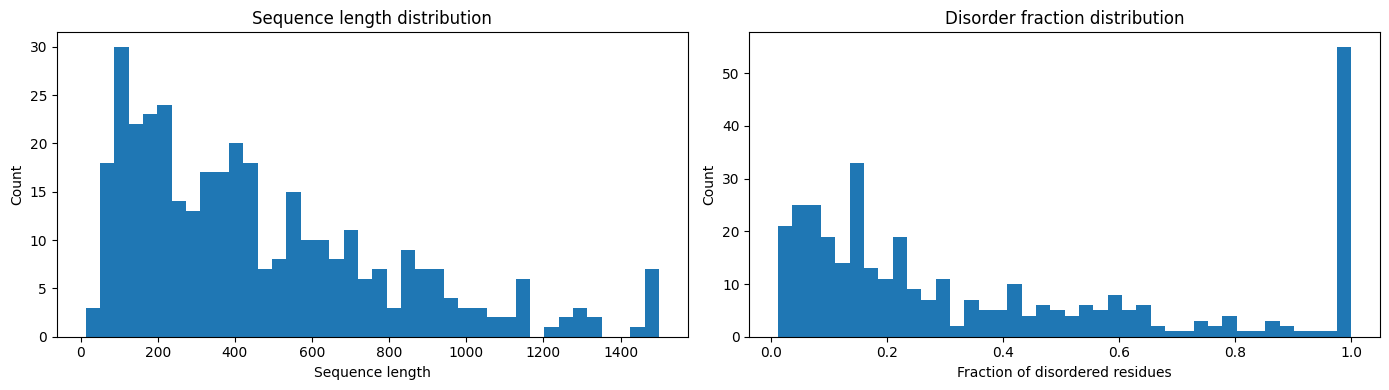

In [9]:
# ================================================================
# Cell 7 - Quick dataset inspection plots
# ================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(proteins_df['seq_len'], bins=40)
axes[0].set_title('Sequence length distribution')
axes[0].set_xlabel('Sequence length')
axes[0].set_ylabel('Count')

axes[1].hist(proteins_df['disorder_fraction'], bins=40)
axes[1].set_title('Disorder fraction distribution')
axes[1].set_xlabel('Fraction of disordered residues')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()

### Data Splitting: Training, Validation, and Testing

This cell splits the protein data into training, validation, and test sets at the protein level. It uses stratified sampling based on disorder fraction to ensure balanced representation across splits, preventing data leakage and enabling robust model evaluation.

In [10]:
# ================================================================
# Cell 8 - Protein-level train/validation/test split
# ================================================================
# We split proteins, not residues, so residues from the same protein never
# appear in multiple splits. Stratification is used only when every bin has
# enough proteins for scikit-learn to split safely.

proteins_df['strat_bin'] = pd.cut(
    proteins_df['disorder_fraction'],
    bins=[-1e-9, 0.33, 0.66, 1.0],
    labels=False,
)

def can_stratify(series: pd.Series) -> bool:
    counts = series.value_counts(dropna=True)
    return len(counts) > 1 and counts.min() >= 2

first_stratify = proteins_df['strat_bin'] if can_stratify(proteins_df['strat_bin']) else None
train_df, temp_df = train_test_split(
    proteins_df,
    test_size=VAL_FRACTION + TEST_FRACTION,
    random_state=SEED,
    stratify=first_stratify,
)

relative_test_fraction = TEST_FRACTION / (VAL_FRACTION + TEST_FRACTION)
second_stratify = temp_df['strat_bin'] if can_stratify(temp_df['strat_bin']) else None
val_df, test_df = train_test_split(
    temp_df,
    test_size=relative_test_fraction,
    random_state=SEED,
    stratify=second_stratify,
)

print('First split stratified:', first_stratify is not None)
print('Second split stratified:', second_stratify is not None)
for split_name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print(f'{split_name:>5}: {len(split_df):,} proteins | mean disorder fraction = {split_df["disorder_fraction"].mean():.4f}')

First split stratified: True
Second split stratified: True
train: 254 proteins | mean disorder fraction = 0.3857
  val: 54 proteins | mean disorder fraction = 0.3938
 test: 55 proteins | mean disorder fraction = 0.3660


In [11]:
# ================================================================
# Cell X - ESM-2 embedding initialization (moved from original Cell 25)
# ================================================================
# This section is enabled because RUN_ESM2_SECTION is set to True.
# It installs `fair-esm`, loads a pre-trained ESM-2 model, and defines
# `extract_esm2_embeddings` for context-aware residue features.

# Only run if ESM-2 section is enabled (set in Cell 2)
if RUN_ESM2_SECTION:
    %pip -q install fair-esm
    import esm
    esm_model, esm_alphabet = esm.pretrained.esm2_t6_8M_UR50D()
    esm_model = esm_model.to(device)
    esm_model.eval()
    batch_converter = esm_alphabet.get_batch_converter()

    def extract_esm2_embeddings(sequence: str):
        batch = [('protein', sequence)]
        _, _, tokens = batch_converter(batch)
        tokens = tokens.to(device)
        with torch.no_grad():
            output = esm_model(tokens, repr_layers=[6])
        return output['representations'][6][0, 1:-1].cpu().numpy()
    print('ESM-2 embeddings setup complete. `extract_esm2_embeddings` is now available.')
else:
    print('ESM-2 section is disabled. `extract_esm2_embeddings` will not be defined.')

ESM-2 section is disabled. `extract_esm2_embeddings` will not be defined.


### Residue Feature Engineering: Stronger IDR-Specific Features

This cell transforms raw protein sequences into numerical residue features. The default feature set is now stronger than plain one-hot encoding: it includes amino acid identity, physicochemical values, IDR propensity, residue group flags, positional features, and sliding-window composition statistics. If ESM-2 is enabled, these handcrafted features are concatenated with ESM-2 embeddings instead of replaced.

In [12]:
# ================================================================
# Cell 9 - Residue feature engineering
# ================================================================
# The default path uses IDR-aware handcrafted features. These are much more
# informative than one-hot + raw physicochemical values alone, especially when
# ESM-2 is disabled.

AMINO_ACIDS = list('ACDEFGHIKLMNPQRSTVWY')
VALID_AA_SET = set(AMINO_ACIDS)

AA_TO_INDEX = {aa: i for i, aa in enumerate(AMINO_ACIDS)}
PHYSICOCHEM = {
    'A': [1.8,  89.1,  0, 1, 0, 0, 0],
    'C': [2.5, 121.2,  0, 1, 0, 0, 1],
    'D': [-3.5, 133.1, -1, 0, 0, 1, 0],
    'E': [-3.5, 147.1, -1, 0, 0, 1, 0],
    'F': [2.8, 165.2,  0, 1, 1, 0, 0],
    'G': [-0.4, 75.1,  0, 0, 0, 0, 0],
    'H': [-3.2, 155.2,  1, 0, 1, 0, 0],
    'I': [4.5, 131.2,  0, 1, 0, 0, 0],
    'K': [-3.9, 146.2,  1, 0, 0, 0, 0],
    'L': [3.8, 131.2,  0, 1, 0, 0, 0],
    'M': [1.9, 149.2,  0, 1, 0, 0, 1],
    'N': [-3.5, 132.1,  0, 0, 0, 1, 0],
    'P': [-1.6, 115.1,  0, 0, 0, 0, 0],
    'Q': [-3.5, 146.1,  0, 0, 0, 1, 0],
    'R': [-4.5, 174.2,  1, 0, 0, 0, 0],
    'S': [-0.8, 105.1,  0, 0, 0, 1, 0],
    'T': [-0.7, 119.1,  0, 0, 0, 1, 0],
    'V': [4.2, 117.1,  0, 1, 0, 0, 0],
    'W': [-0.9, 204.2,  0, 1, 1, 0, 0],
    'Y': [-1.3, 181.2,  0, 0, 1, 1, 0],
}
PHYSICOCHEM_KEYS = ['hydropathy', 'mass', 'positive', 'hydrophobic', 'aromatic', 'polar', 'sulfur']

# Disorder-promoting propensity: larger values roughly indicate residues more
# common in IDRs; order-promoting hydrophobics receive lower values.
DISORDER_PROPENSITY = {
    'A': 0.06, 'C': -0.45, 'D': 0.40, 'E': 0.42, 'F': -0.55,
    'G': 0.30, 'H': 0.05, 'I': -0.65, 'K': 0.35, 'L': -0.55,
    'M': -0.20, 'N': 0.28, 'P': 0.55, 'Q': 0.32, 'R': 0.20,
    'S': 0.38, 'T': 0.18, 'V': -0.50, 'W': -0.70, 'Y': -0.35,
}

GROUPS = {
    'charged': set('DEKRH'),
    'positive': set('KRH'),
    'negative': set('DE'),
    'polar': set('STNQDEKRH'),
    'hydrophobic': set('AILMFWYV'),
    'aromatic': set('FWYH'),
    'proline': set('P'),
    'glycine': set('G'),
    'low_complexity': set('PGSQDENK'),
}

phys_matrix = np.array([PHYSICOCHEM[aa] for aa in AMINO_ACIDS], dtype=np.float32)
phys_mean = phys_matrix.mean(axis=0, keepdims=True)
phys_std = phys_matrix.std(axis=0, keepdims=True) + 1e-8
prop_values = np.array([DISORDER_PROPENSITY[aa] for aa in AMINO_ACIDS], dtype=np.float32)
prop_mean = float(prop_values.mean())
prop_std = float(prop_values.std() + 1e-8)

def _rolling_mean(values: np.ndarray, window: int) -> np.ndarray:
    if len(values) == 0:
        return values.astype(np.float32)
    pad_left = window // 2
    pad_right = window - 1 - pad_left
    padded = np.pad(values.astype(np.float32), (pad_left, pad_right), mode='edge')
    kernel = np.ones(window, dtype=np.float32) / float(window)
    return np.convolve(padded, kernel, mode='valid').astype(np.float32)

def handcrafted_sequence_features(sequence: str) -> np.ndarray:
    n = len(sequence)
    one_hot = np.zeros((n, len(AMINO_ACIDS)), dtype=np.float32)
    phys = np.zeros((n, len(PHYSICOCHEM_KEYS)), dtype=np.float32)
    propensity = np.zeros((n, 1), dtype=np.float32)
    group_features = np.zeros((n, len(GROUPS)), dtype=np.float32)

    for i, aa in enumerate(sequence):
        aa_idx = AA_TO_INDEX[aa]
        one_hot[i, aa_idx] = 1.0
        phys[i] = np.array(PHYSICOCHEM[aa], dtype=np.float32)
        propensity[i, 0] = DISORDER_PROPENSITY[aa]
        for j, residues in enumerate(GROUPS.values()):
            group_features[i, j] = 1.0 if aa in residues else 0.0

    phys = (phys - phys_mean) / phys_std
    propensity = (propensity - prop_mean) / prop_std

    positions = np.linspace(0.0, 1.0, n, dtype=np.float32).reshape(-1, 1)
    terminal_distance = np.minimum(positions, 1.0 - positions).astype(np.float32)

    hydropathy = np.array([PHYSICOCHEM[aa][0] for aa in sequence], dtype=np.float32)
    charge = np.array([PHYSICOCHEM[aa][2] for aa in sequence], dtype=np.float32)
    prop = np.array([DISORDER_PROPENSITY[aa] for aa in sequence], dtype=np.float32)
    polar = group_features[:, list(GROUPS.keys()).index('polar')]
    hydrophobic = group_features[:, list(GROUPS.keys()).index('hydrophobic')]
    charged = group_features[:, list(GROUPS.keys()).index('charged')]
    proline = group_features[:, list(GROUPS.keys()).index('proline')]
    glycine = group_features[:, list(GROUPS.keys()).index('glycine')]
    low_complexity = group_features[:, list(GROUPS.keys()).index('low_complexity')]

    window_features = []
    for window in [9, 21, 41]:
        window_features.extend([
            _rolling_mean(hydropathy, window),
            _rolling_mean(charge, window),
            np.abs(_rolling_mean(charge, window)),
            _rolling_mean(prop, window),
            _rolling_mean(polar, window),
            _rolling_mean(hydrophobic, window),
            _rolling_mean(charged, window),
            _rolling_mean(proline + glycine, window),
            _rolling_mean(low_complexity, window),
        ])
    window_features = np.stack(window_features, axis=1).astype(np.float32)

    # Normalize rolling features within each sequence to keep scales stable.
    window_features = (window_features - window_features.mean(axis=0, keepdims=True)) / (window_features.std(axis=0, keepdims=True) + 1e-6)

    return np.concatenate([
        one_hot,
        phys,
        propensity,
        group_features,
        positions,
        terminal_distance,
        window_features,
    ], axis=1).astype(np.float32)

def encode_sequence(sequence: str) -> np.ndarray:
    handcrafted = handcrafted_sequence_features(sequence)
    if RUN_ESM2_SECTION:
        esm_features = extract_esm2_embeddings(sequence).astype(np.float32)
        return np.concatenate([esm_features, handcrafted], axis=1)
    return handcrafted

sample_features = encode_sequence(proteins_df.iloc[0]['sequence'])
print('Feature matrix shape for one protein:', sample_features.shape)
print('Feature dimension per residue:', sample_features.shape[1])
print('Feature mode:', 'ESM-2 + handcrafted IDR features' if RUN_ESM2_SECTION else 'handcrafted IDR features')


Feature matrix shape for one protein: (227, 66)
Feature dimension per residue: 66
Feature mode: handcrafted IDR features


### PyTorch Dataset and DataLoader: Efficient Data Handling

This cell defines a `ProteinResidueDataset` to efficiently prepare protein sequences and labels, and a `collate_batch` function to handle variable sequence lengths by padding and masking. It then creates PyTorch `DataLoader` instances for training, validation, and testing.

In [13]:
# ================================================================
# Cell 10 - PyTorch dataset and collate function
# ================================================================
# We pad variable-length proteins within each batch and use a mask so the
# padded positions never contribute to the loss or metrics.

class ProteinResidueDataset(Dataset):
    def __init__(self, df: pd.DataFrame):
        self.records = []
        for _, row in df.iterrows():
            features = encode_sequence(row['sequence'])
            labels = row['labels'].astype(np.float32)
            self.records.append({
                'protein_id': row['protein_id'],
                'sequence': row['sequence'],
                'features': features,
                'labels': labels,
            })

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        return self.records[idx]


def collate_batch(batch):
    max_len = max(len(item['sequence']) for item in batch)
    feature_dim = batch[0]['features'].shape[1]
    features = np.zeros((len(batch), max_len, feature_dim), dtype=np.float32)
    labels = np.zeros((len(batch), max_len), dtype=np.float32)
    mask = np.zeros((len(batch), max_len), dtype=np.float32)
    protein_ids, sequences = [], []
    for i, item in enumerate(batch):
        seq_len = len(item['sequence'])
        features[i, :seq_len] = item['features']
        labels[i, :seq_len] = item['labels']
        mask[i, :seq_len] = 1.0
        protein_ids.append(item['protein_id'])
        sequences.append(item['sequence'])
    return {
        'protein_ids': protein_ids,
        'sequences': sequences,
        'features': torch.tensor(features, dtype=torch.float32),
        'labels': torch.tensor(labels, dtype=torch.float32),
        'mask': torch.tensor(mask, dtype=torch.float32),
    }

train_dataset = ProteinResidueDataset(train_df)
val_dataset = ProteinResidueDataset(val_df)
test_dataset = ProteinResidueDataset(test_df)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)

first_batch = next(iter(train_loader))
print('Batch features shape:', tuple(first_batch['features'].shape))
print('Batch labels shape:', tuple(first_batch['labels'].shape))
print('Batch mask shape:', tuple(first_batch['mask'].shape))

Batch features shape: (16, 1497, 66)
Batch labels shape: (16, 1497)
Batch mask shape: (16, 1497)


### Defining Our Neural Network: HybridDisorderNet

This cell defines HybridDisorderNet, a stronger residue-level architecture for intrinsic disorder prediction.

The model combines four complementary views of a protein sequence:
- **multi-scale residual CNN branches** for short local motifs and composition patterns
- **Transformer self-attention** for long-range residue interactions
- **bidirectional LSTM context** for ordered left-to-right and right-to-left sequence smoothing
- **learned gated fusion** so the model can choose how much to trust local, attention-based, and recurrent context at each residue

In [14]:
# ================================================================
# Cell 11 - Define HybridDisorderNet
# ================================================================
# Architecture intuition:
#   1. Project residue features into a shared hidden space.
#   2. Use parallel convolutions to capture local IDR motifs at multiple scales.
#   3. Use Transformer attention to model long-range residue dependencies.
#   4. Use a BiLSTM to smooth sequential context in both directions.
#   5. Learn a per-residue gate that fuses local, attention, and recurrent features.

class MultiScaleResidualConv(nn.Module):
    def __init__(self, hidden_dim, kernel_sizes=(3, 7, 15), dropout=0.25):
        super().__init__()
        self.branches = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(hidden_dim, hidden_dim, kernel_size=k, padding=k // 2),
                nn.BatchNorm1d(hidden_dim),
                nn.GELU(),
                nn.Dropout(dropout),
            )
            for k in kernel_sizes
        ])
        self.fuse = nn.Sequential(
            nn.Conv1d(hidden_dim * len(kernel_sizes), hidden_dim, kernel_size=1),
            nn.BatchNorm1d(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.out_norm = nn.LayerNorm(hidden_dim)

    def forward(self, x, mask=None):
        residual = x
        z = x.transpose(1, 2)
        branch_outputs = [branch(z) for branch in self.branches]
        z = self.fuse(torch.cat(branch_outputs, dim=1)).transpose(1, 2)
        if mask is not None:
            z = z * mask.unsqueeze(-1)
        return self.out_norm(residual + z)


class HybridDisorderNet(nn.Module):
    def __init__(
        self,
        input_dim,
        hidden_dim=96,
        transformer_layers=2,
        transformer_heads=4,
        conv_kernel_sizes=(3, 7, 15),
        dropout=0.25,
        max_len=1500,
    ):
        super().__init__()
        if hidden_dim % 2 != 0:
            raise ValueError('hidden_dim must be even for the bidirectional LSTM.')
        if hidden_dim % transformer_heads != 0:
            raise ValueError('hidden_dim must be divisible by transformer_heads.')

        self.max_len = max_len
        self.input_norm = nn.LayerNorm(input_dim)
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.position_embedding = nn.Parameter(torch.zeros(1, max_len, hidden_dim))
        nn.init.normal_(self.position_embedding, mean=0.0, std=0.02)

        self.local_encoder = MultiScaleResidualConv(
            hidden_dim=hidden_dim,
            kernel_sizes=conv_kernel_sizes,
            dropout=dropout,
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=transformer_heads,
            dim_feedforward=hidden_dim * 4,
            dropout=dropout,
            activation='gelu',
            batch_first=True,
            norm_first=True,
        )
        self.global_encoder = nn.TransformerEncoder(encoder_layer, num_layers=transformer_layers)

        self.sequence_encoder = nn.LSTM(
            hidden_dim,
            hidden_dim // 2,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=dropout,
        )

        self.fusion_gate = nn.Sequential(
            nn.Linear(hidden_dim * 3, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 3),
        )
        self.output_norm = nn.LayerNorm(hidden_dim)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x, mask=None):
        batch_size, seq_len, _ = x.shape
        if seq_len > self.max_len:
            raise ValueError(f'Sequence length {seq_len} exceeds configured max_len={self.max_len}.')
        if mask is None:
            mask = torch.ones(batch_size, seq_len, device=x.device, dtype=x.dtype)
        mask = mask.float()
        pad_mask = mask == 0

        x = self.input_norm(x)
        h = self.input_proj(x)
        h = h + self.position_embedding[:, :seq_len, :]
        h = h * mask.unsqueeze(-1)

        local_features = self.local_encoder(h, mask=mask)
        global_features = self.global_encoder(local_features, src_key_padding_mask=pad_mask)
        global_features = global_features * mask.unsqueeze(-1)

        sequence_features, _ = self.sequence_encoder(global_features)
        sequence_features = sequence_features * mask.unsqueeze(-1)

        stacked_features = torch.stack([local_features, global_features, sequence_features], dim=2)
        fusion_input = torch.cat([local_features, global_features, sequence_features], dim=-1)
        fusion_weights = torch.softmax(self.fusion_gate(fusion_input), dim=-1).unsqueeze(-1)
        fused = (stacked_features * fusion_weights).sum(dim=2)
        fused = self.output_norm(fused)
        return self.classifier(fused).squeeze(-1)


input_dim = train_dataset[0]['features'].shape[1]
model = HybridDisorderNet(
    input_dim=input_dim,
    hidden_dim=HIDDEN_DIM,
    transformer_layers=TRANSFORMER_LAYERS,
    transformer_heads=TRANSFORMER_HEADS,
    conv_kernel_sizes=CONV_KERNEL_SIZES,
    dropout=DROPOUT,
    max_len=MAX_SEQ_LEN,
).to(device)
print(model)
print('Trainable parameters:', f'{sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

HybridDisorderNet(
  (input_norm): LayerNorm((66,), eps=1e-05, elementwise_affine=True)
  (input_proj): Sequential(
    (0): Linear(in_features=66, out_features=128, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.2, inplace=False)
  )
  (local_encoder): MultiScaleResidualConv(
    (branches): ModuleList(
      (0): Sequential(
        (0): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
        (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): GELU(approximate='none')
        (3): Dropout(p=0.2, inplace=False)
      )
      (1): Sequential(
        (0): Conv1d(128, 128, kernel_size=(7,), stride=(1,), padding=(3,))
        (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): GELU(approximate='none')
        (3): Dropout(p=0.2, inplace=False)
      )
      (2): Sequential(
        (0): Conv1d(128, 128, kernel_size=(15,), stride=(1,), padding=(7,))
        (1): B

### Loss Function, Optimizer, and Metric Helpers

This cell sets up the training essentials: `nn.BCEWithLogitsLoss` (with positive class weighting for imbalance) as the loss function, `torch.optim.AdamW` as the optimizer, and helper functions like `masked_bce_loss` and `compute_classification_metrics` for evaluating model performance.

In [15]:
# ================================================================
# Cell 12 - Loss, optimizer, and metric helpers
# ================================================================

all_train_labels = np.concatenate([row['labels'] for row in train_dataset.records])
positive_fraction = float(all_train_labels.mean())
negative_fraction = 1.0 - positive_fraction
pos_weight = torch.tensor(max(negative_fraction / max(positive_fraction, 1e-6), 1.0), device=device)
criterion = nn.BCEWithLogitsLoss(reduction='none', pos_weight=pos_weight)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3,
    min_lr=1e-5,
)

print('Training positive fraction:', round(positive_fraction, 4))
print('Using positive class weight:', float(pos_weight.cpu().item()))
print('Using focal BCE gamma:', FOCAL_GAMMA)

def masked_bce_loss(logits, labels, mask):
    per_pos_loss = criterion(logits, labels)
    if FOCAL_GAMMA and FOCAL_GAMMA > 0:
        probs = torch.sigmoid(logits)
        p_t = probs * labels + (1.0 - probs) * (1.0 - labels)
        focal_factor = (1.0 - p_t).clamp_min(1e-6).pow(FOCAL_GAMMA)
        per_pos_loss = per_pos_loss * focal_factor
    masked = per_pos_loss * mask
    return masked.sum() / mask.sum().clamp_min(1.0)

def flatten_masked(y_true, y_prob, mask):
    y_true = y_true.reshape(-1)
    y_prob = y_prob.reshape(-1)
    mask = mask.reshape(-1).astype(bool)
    return y_true[mask], y_prob[mask]

def compute_classification_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    specificity = tn / max(tn + fp, 1)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred) if len(np.unique(y_true)) > 1 and len(np.unique(y_pred)) > 1 else 0.0
    try:
        roc_auc = roc_auc_score(y_true, y_prob)
    except Exception:
        roc_auc = np.nan
    try:
        aps = average_precision_score(y_true, y_prob)
    except Exception:
        aps = np.nan
    thresholds = np.linspace(0.01, 0.99, 99)
    fmax = 0.0
    best_t = 0.5
    for t in thresholds:
        pred = (y_prob >= t).astype(int)
        p = precision_score(y_true, pred, zero_division=0)
        r = recall_score(y_true, pred, zero_division=0)
        if (p + r) > 0:
            f = 2 * p * r / (p + r)
            if f > fmax:
                fmax = f
                best_t = float(t)
    return {
        'threshold': threshold,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'specificity': specificity,
        'balanced_accuracy': bal_acc,
        'mcc': mcc,
        'roc_auc': roc_auc,
        'aps': aps,
        'fmax': fmax,
        'best_fmax_threshold': best_t,
        'tn': int(tn),
        'fp': int(fp),
        'fn': int(fn),
        'tp': int(tp),
    }


Training positive fraction: 0.2942
Using positive class weight: 2.3988664150238037
Using focal BCE gamma: 1.5


### Training and Evaluation Loop

This cell trains HybridDisorderNet and evaluates it after each epoch. The checkpoint is selected with a combined validation score instead of APS alone, because APS can saturate early on small or easy validation splits. Early stopping only begins after a minimum number of epochs.

In [16]:
# ================================================================
# Cell 13 - Training and evaluation functions
# ================================================================
# Notes:
#   - APS can become 1.0 very early on small or easy validation splits.
#   - To avoid saving an under-trained epoch just because APS saturated, the
#     checkpoint score combines APS, Fmax, MCC, and ROC-AUC.
#   - Early stopping is disabled until MIN_EPOCHS have completed.

@torch.no_grad()
def run_inference(loader, model, return_loss=False):
    model.eval()
    all_probs, all_labels, all_masks = [], [], []
    protein_level_records = []
    running_loss = 0.0
    total_mask = 0.0
    for batch in loader:
        features = batch['features'].to(device)
        labels = batch['labels'].to(device)
        mask = batch['mask'].to(device)
        logits = model(features, mask=mask)
        probs = torch.sigmoid(logits)
        if return_loss:
            loss = masked_bce_loss(logits, labels, mask)
            running_loss += loss.item() * mask.sum().item()
            total_mask += mask.sum().item()
        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.cpu().numpy())
        all_masks.append(mask.cpu().numpy())
        for i, protein_id in enumerate(batch['protein_ids']):
            seq_len = int(mask[i].sum().item())
            protein_level_records.append({
                'protein_id': protein_id,
                'sequence': batch['sequences'][i],
                'y_true': labels[i, :seq_len].cpu().numpy().astype(int),
                'y_prob': probs[i, :seq_len].cpu().numpy(),
            })
    y_prob = np.concatenate([x.reshape(-1) for x in all_probs])
    y_true = np.concatenate([x.reshape(-1) for x in all_labels])
    mask = np.concatenate([x.reshape(-1) for x in all_masks])
    y_true, y_prob = flatten_masked(y_true, y_prob, mask)
    if return_loss:
        avg_loss = running_loss / max(total_mask, 1.0)
        return y_true, y_prob, protein_level_records, avg_loss
    return y_true, y_prob, protein_level_records

def train_one_epoch(loader, model, optimizer):
    model.train()
    running_loss = 0.0
    total_mask = 0.0
    for batch in loader:
        features = batch['features'].to(device)
        labels = batch['labels'].to(device)
        mask = batch['mask'].to(device)
        optimizer.zero_grad()
        logits = model(features, mask=mask)
        loss = masked_bce_loss(logits, labels, mask)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        running_loss += loss.item() * mask.sum().item()
        total_mask += mask.sum().item()
    return running_loss / max(total_mask, 1.0)

def evaluate_loader(loader, model, threshold=0.5):
    y_true, y_prob, protein_records, avg_loss = run_inference(loader, model, return_loss=True)
    metrics = compute_classification_metrics(y_true, y_prob, threshold=threshold)
    metrics['loss'] = avg_loss
    return metrics, y_true, y_prob, protein_records

def checkpoint_score(metrics):
    aps = np.nan_to_num(metrics.get('aps', 0.0), nan=0.0)
    fmax = np.nan_to_num(metrics.get('fmax', 0.0), nan=0.0)
    mcc = np.nan_to_num(metrics.get('mcc', 0.0), nan=0.0)
    roc_auc = np.nan_to_num(metrics.get('roc_auc', 0.0), nan=0.0)
    return 0.40 * aps + 0.30 * fmax + 0.20 * max(mcc, 0.0) + 0.10 * roc_auc

val_residue_count = sum(len(row['labels']) for row in val_dataset.records)
print(f'Validation set: {len(val_dataset):,} proteins | {val_residue_count:,} labeled residues')
if len(val_dataset) < 20 or data_mode == 'embedded_demo':
    print('WARNING: Validation split is small; near-perfect validation metrics may be unstable. Use test metrics and data mode in the final report.')

history = {
    'epoch': [],
    'train_loss': [],
    'val_loss': [],
    'val_aps': [],
    'val_f1': [],
    'val_fmax': [],
    'val_mcc': [],
    'val_roc_auc': [],
    'checkpoint_score': [],
}
best_val_score = -np.inf
best_checkpoint_path = CHECKPOINT_DIR / 'best_hybrid_disordernet_model.pt'
patience_counter = 0

for epoch in range(1, NUM_EPOCHS + 1):
    start_time = time.time()
    train_loss = train_one_epoch(train_loader, model, optimizer)
    val_metrics, _, _, _ = evaluate_loader(val_loader, model, threshold=0.5)
    scheduler.step(val_metrics['loss'])
    current_lr = optimizer.param_groups[0]['lr']
    elapsed = time.time() - start_time
    score_for_checkpoint = float(checkpoint_score(val_metrics))

    history['epoch'].append(epoch)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_metrics['loss'])
    history['val_aps'].append(val_metrics['aps'])
    history['val_f1'].append(val_metrics['f1'])
    history['val_fmax'].append(val_metrics['fmax'])
    history['val_mcc'].append(val_metrics['mcc'])
    history['val_roc_auc'].append(val_metrics['roc_auc'])
    history['checkpoint_score'].append(score_for_checkpoint)

    improved = score_for_checkpoint > (best_val_score + EARLY_STOPPING_MIN_DELTA)
    if improved:
        best_val_score = score_for_checkpoint
        patience_counter = 0
        torch.save({
            'model_state_dict': model.state_dict(),
            'config': {
                'model_name': MODEL_NAME,
                'input_dim': input_dim,
                'hidden_dim': HIDDEN_DIM,
                'transformer_layers': TRANSFORMER_LAYERS,
                'transformer_heads': TRANSFORMER_HEADS,
                'conv_kernel_sizes': CONV_KERNEL_SIZES,
                'dropout': DROPOUT,
                'max_len': MAX_SEQ_LEN,
                'run_esm2_section': RUN_ESM2_SECTION,
                'checkpoint_score_name': '0.40*APS + 0.30*Fmax + 0.20*MCC + 0.10*ROC_AUC',
                'focal_gamma': FOCAL_GAMMA,
                'feature_mode': 'esm2_plus_handcrafted' if RUN_ESM2_SECTION else 'handcrafted_idr',
            },
            'history': history,
            'best_val_metrics': val_metrics,
            'best_checkpoint_score': best_val_score,
        }, best_checkpoint_path)
    else:
        patience_counter += 1

    print(
        f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_metrics['loss']:.4f} | "
        f"val_APS={val_metrics['aps']:.4f} | val_Fmax={val_metrics['fmax']:.4f} | "
        f"val_MCC={val_metrics['mcc']:.4f} | val_ROC_AUC={val_metrics['roc_auc']:.4f} | "
        f"score={score_for_checkpoint:.4f} | lr={current_lr:.2e} | time={elapsed:.1f}s"
    )

    if epoch == 1 and val_metrics['aps'] >= 0.999 and val_metrics['roc_auc'] >= 0.999:
        print('NOTE: Validation APS/ROC-AUC are already near-perfect. This usually means the validation split is small/easy or sequence similarity remains across splits.')

    if epoch >= MIN_EPOCHS and patience_counter >= EARLY_STOPPING_PATIENCE:
        print(f'Early stopping triggered after epoch {epoch}.')
        break

print('Best checkpoint saved to:', best_checkpoint_path)
print('Best validation checkpoint score:', round(best_val_score, 4))

Validation set: 54 proteins | 25,593 labeled residues
Epoch 01 | train_loss=0.3381 | val_loss=0.3084 | val_APS=0.4404 | val_Fmax=0.5238 | val_MCC=0.2761 | val_ROC_AUC=0.7152 | score=0.4600 | lr=1.00e-03 | time=4.2s
Epoch 02 | train_loss=0.3170 | val_loss=0.2935 | val_APS=0.5133 | val_Fmax=0.5712 | val_MCC=0.3549 | val_ROC_AUC=0.7668 | score=0.5243 | lr=1.00e-03 | time=1.8s
Epoch 03 | train_loss=0.3118 | val_loss=0.2825 | val_APS=0.5288 | val_Fmax=0.5768 | val_MCC=0.3848 | val_ROC_AUC=0.7781 | score=0.5394 | lr=1.00e-03 | time=1.8s
Epoch 04 | train_loss=0.2919 | val_loss=0.2753 | val_APS=0.5981 | val_Fmax=0.5812 | val_MCC=0.3938 | val_ROC_AUC=0.7896 | score=0.5713 | lr=1.00e-03 | time=1.8s
Epoch 05 | train_loss=0.2874 | val_loss=0.2653 | val_APS=0.5968 | val_Fmax=0.6059 | val_MCC=0.4286 | val_ROC_AUC=0.8083 | score=0.5870 | lr=1.00e-03 | time=1.8s
Epoch 06 | train_loss=0.2750 | val_loss=0.2643 | val_APS=0.6167 | val_Fmax=0.6057 | val_MCC=0.4354 | val_ROC_AUC=0.8136 | score=0.5968 | lr=1

### Loading the Best Model

This cell loads the best-performing checkpoint saved during training. The checkpoint is chosen using the combined validation score, while the printed metrics show the APS, Fmax, MCC, and ROC-AUC for that selected epoch.

In [17]:
# ================================================================
# Cell 14 - Load the best checkpoint before final evaluation
# ================================================================

checkpoint = torch.load(best_checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
best_metrics = checkpoint['best_val_metrics']
FINAL_THRESHOLD = float(best_metrics.get('best_fmax_threshold', 0.5))
print('Loaded best checkpoint for', checkpoint['config'].get('model_name', MODEL_NAME))
print('Checkpoint score =', round(checkpoint.get('best_checkpoint_score', float('nan')), 4))
print('Final decision threshold from validation Fmax =', round(FINAL_THRESHOLD, 3))
print(
    'Validation metrics:',
    f"APS={best_metrics['aps']:.4f}",
    f"Fmax={best_metrics['fmax']:.4f}",
    f"MCC={best_metrics['mcc']:.4f}",
    f"ROC-AUC={best_metrics['roc_auc']:.4f}",
)


Loaded best checkpoint for HybridDisorderNet
Checkpoint score = 0.5968
Final decision threshold from validation Fmax = 0.49
Validation metrics: APS=0.6167 Fmax=0.6057 MCC=0.4354 ROC-AUC=0.8136


### Visualizing Training Progress

This cell plots training loss, validation loss, validation APS, and the combined checkpoint score. If APS is flat at 1.0, use the validation loss and checkpoint score curves to see whether training is still changing.

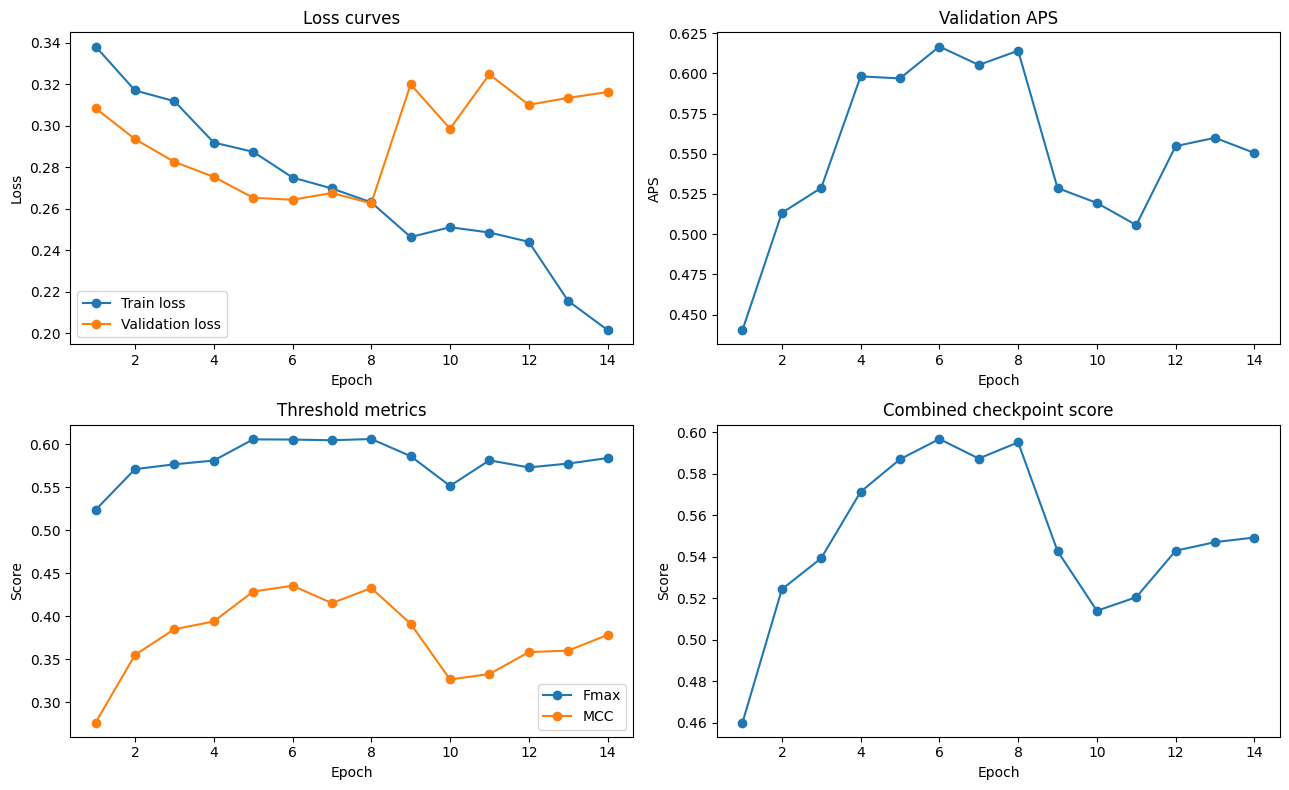

In [18]:
# ================================================================
# Cell 15 - Plot the training curves
# ================================================================

history_df = pd.DataFrame(history)
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.ravel()

axes[0].plot(history_df['epoch'], history_df['train_loss'], marker='o', label='Train loss')
if 'val_loss' in history_df:
    axes[0].plot(history_df['epoch'], history_df['val_loss'], marker='o', label='Validation loss')
axes[0].set_title('Loss curves')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_df['epoch'], history_df['val_aps'], marker='o')
axes[1].set_title('Validation APS')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('APS')

axes[2].plot(history_df['epoch'], history_df['val_fmax'], marker='o', label='Fmax')
axes[2].plot(history_df['epoch'], history_df['val_mcc'], marker='o', label='MCC')
axes[2].set_title('Threshold metrics')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Score')
axes[2].legend()

axes[3].plot(history_df['epoch'], history_df['checkpoint_score'], marker='o')
axes[3].set_title('Combined checkpoint score')
axes[3].set_xlabel('Epoch')
axes[3].set_ylabel('Score')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### Final Test-Set Evaluation

This cell evaluates the best model on the unseen test set. Instead of using a fixed `0.5` threshold, it uses the threshold selected on the validation set by Fmax. This usually gives a fairer F1/MCC estimate for imbalanced residue-level disorder labels.

In [19]:
# ================================================================
# Cell 16 - Final test-set evaluation metrics
# ================================================================

test_metrics, y_true_test, y_prob_test, test_protein_records = evaluate_loader(test_loader, model, threshold=FINAL_THRESHOLD)
test_metrics_df = pd.DataFrame([test_metrics])
test_metrics_df['threshold_source'] = 'validation_fmax'
test_metrics_df.to_csv(TABLES_DIR / 'test_metrics.csv', index=False)
print('Using final threshold:', round(FINAL_THRESHOLD, 3))
print(test_metrics_df.T)


Using final threshold: 0.49
                                   0
threshold                       0.49
precision                   0.498061
recall                      0.845045
f1                          0.626732
specificity                 0.694195
balanced_accuracy            0.76962
mcc                         0.478079
roc_auc                     0.843586
aps                         0.653732
fmax                        0.628544
best_fmax_threshold              0.5
tn                             13811
fp                              6084
fn                              1107
tp                              6037
loss                        0.241078
threshold_source     validation_fmax


### Precision-Recall Curve

This cell plots the Precision-Recall curve for the test set, visualizing the trade-off between precision and recall across different thresholds. It's especially useful for imbalanced datasets and is titled with the Average Precision Score (APS).

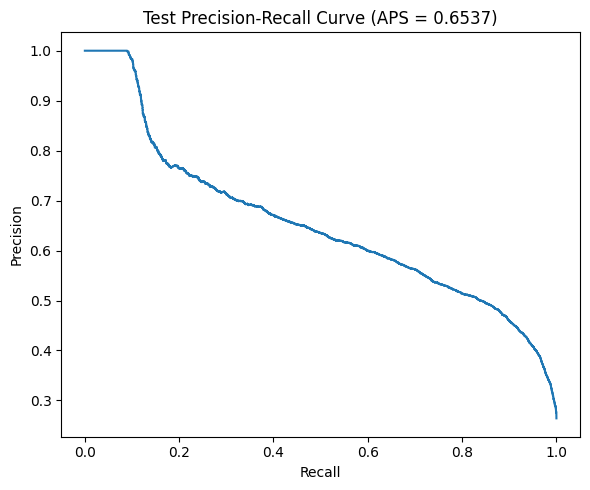

In [20]:
# ================================================================
# Cell 17 - Precision-recall curve on the test set
# ================================================================

precision_vals, recall_vals, _ = precision_recall_curve(y_true_test, y_prob_test)
plt.figure(figsize=(6, 5))
plt.plot(recall_vals, precision_vals)
plt.title(f"Test Precision-Recall Curve (APS = {test_metrics['aps']:.4f})")
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'precision_recall_curve.png', dpi=150, bbox_inches='tight')
plt.show()

### Confusion Matrix

This cell generates and visualizes a confusion matrix for the test set at the validation-selected threshold. The heatmap shows true positives, true negatives, false positives, and false negatives.

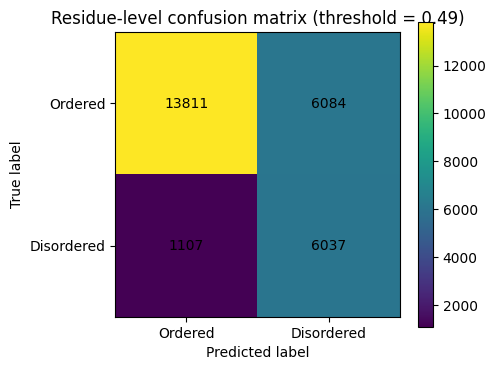

In [21]:
# ================================================================
# Cell 18 - Confusion matrix at validation-selected threshold
# ================================================================

y_pred_test = (y_prob_test >= FINAL_THRESHOLD).astype(int)
cm = confusion_matrix(y_true_test, y_pred_test, labels=[0, 1])
plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title(f'Residue-level confusion matrix (threshold = {FINAL_THRESHOLD:.2f})')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.xticks([0, 1], ['Ordered', 'Disordered'])
plt.yticks([0, 1], ['Ordered', 'Disordered'])
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center')
plt.colorbar()
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


### Per-Protein Metrics

This cell calculates and displays detailed performance metrics (precision, recall, F1, MCC, APS, ROC-AUC) for each individual protein in the test set. The results are stored in a DataFrame, sorted to highlight top-performing predictions.

In [22]:
# ================================================================
# Cell 19 - Per-protein metrics on the test set
# ================================================================

per_protein_rows = []
for rec in test_protein_records:
    metrics = compute_classification_metrics(rec['y_true'], rec['y_prob'], threshold=FINAL_THRESHOLD)
    per_protein_rows.append({
        'protein_id': rec['protein_id'],
        'seq_len': len(rec['sequence']),
        'disorder_fraction_true': float(np.mean(rec['y_true'])),
        'threshold': FINAL_THRESHOLD,
        'precision': metrics['precision'],
        'recall': metrics['recall'],
        'f1': metrics['f1'],
        'mcc': metrics['mcc'],
        'aps': metrics['aps'],
        'roc_auc': metrics['roc_auc'],
    })
per_protein_df = pd.DataFrame(per_protein_rows).sort_values(['aps', 'f1'], ascending=False)
per_protein_df.to_csv(TABLES_DIR / 'per_protein_test_metrics.csv', index=False)
per_protein_df.head(10)


,protein_id,seq_len,disorder_fraction_true,threshold,precision,recall,f1,mcc,aps,roc_auc
0,DP03404,112,1.0,0.49,1.0,1.000000,1.000000,0.0,1.0,NaN
5,DP03392,257,1.0,0.49,1.0,1.000000,1.000000,0.0,1.0,NaN
14,DP03982,210,1.0,0.49,1.0,1.000000,1.000000,0.0,1.0,NaN
26,DP03066,183,1.0,0.49,1.0,1.000000,1.000000,0.0,1.0,NaN
34,DP03000,456,1.0,0.49,1.0,1.000000,1.000000,0.0,1.0,NaN
13,DP03367,103,1.0,0.49,1.0,0.427184,0.598639,0.0,1.0,NaN
12,DP03705,75,1.0,0.49,1.0,1.000000,1.000000,0.0,1.0,NaN
52,DP04016,635,1.0,0.49,1.0,0.976378,0.988048,0.0,1.0,NaN
15,DP04011,71,1.0,0.49,1.0,1.000000,1.000000,0.0,1.0,NaN
23,DP04244,109,1.0,0.49,1.0,0.743119,0.852632,0.0,1.0,NaN


### Sample Prediction Trace

This cell visualizes the model's prediction for a sample protein from the test set. It plots the predicted disorder probability alongside the true disorder labels for each residue, providing a clear, residue-level view of the model's performance.

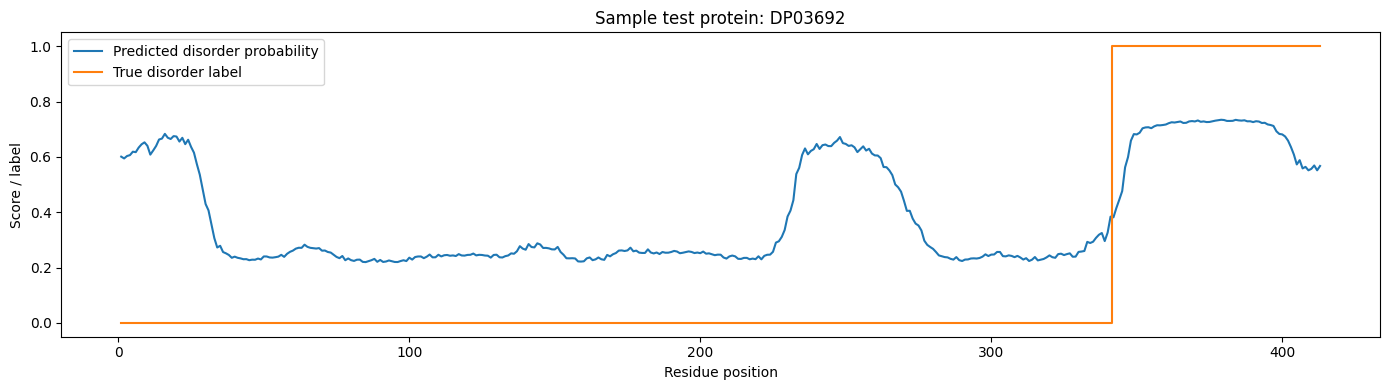

In [23]:
# ================================================================
# Cell 20 - Plot a sample protein prediction trace
# ================================================================

sample_record = sorted(test_protein_records, key=lambda x: len(x['sequence']))[len(test_protein_records) // 2]
residue_positions = np.arange(1, len(sample_record['sequence']) + 1)
plt.figure(figsize=(14, 4))
plt.plot(residue_positions, sample_record['y_prob'], label='Predicted disorder probability')
plt.step(residue_positions, sample_record['y_true'], where='mid', label='True disorder label')
plt.ylim(-0.05, 1.05)
plt.xlabel('Residue position')
plt.ylabel('Score / label')
plt.title(f"Sample test protein: {sample_record['protein_id']}")
plt.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'sample_prediction_trace.png', dpi=150, bbox_inches='tight')
plt.show()

### Custom Sequence Prediction

This interactive cell allows you to input your own protein sequence. The trained model will then predict its intrinsically disordered regions, displaying residue-level disorder probabilities and binary labels in a DataFrame and visualizing them on a plot.

    position residue  predicted_disorder_probability  \
0          1       M                        0.628990   
1          2       S                        0.634558   
2          3       E                        0.620785   
3          4       Q                        0.638124   
4          5       N                        0.631390   
5          6       N                        0.632608   
6          7       T                        0.635343   
7          8       E                        0.612460   
8          9       M                        0.620136   
9         10       T                        0.595928   
10        11       F                        0.612046   
11        12       Q                        0.583705   
12        13       I                        0.609962   
13        14       Q                        0.608476   
14        15       R                        0.552268   
15        16       I                        0.618520   
16        17       Y                        0.53

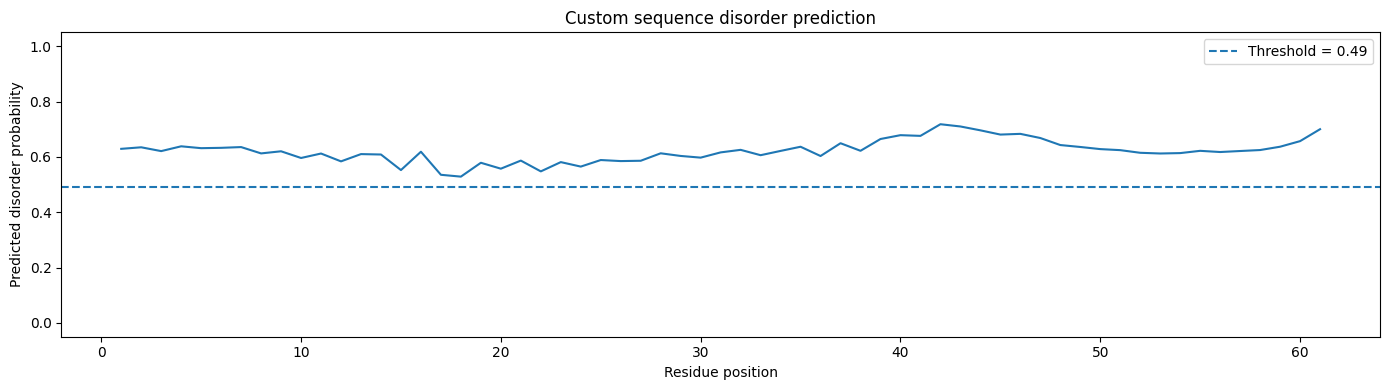

In [24]:
# ================================================================
# Cell 21 - Predict on a custom sequence
# ================================================================
# Replace CUSTOM_SEQUENCE with any valid sequence using only the 20 standard
# amino acid letters.

CUSTOM_SEQUENCE = 'MSEQNNTEMTFQIQRIYTKDISFEAPNAPHVFQKDWLDLSEKKKQQQQQQQQQQQQQQQQQ'
custom_sequence = CUSTOM_SEQUENCE.strip().upper()
assert set(custom_sequence).issubset(VALID_AA_SET), 'Custom sequence contains unsupported characters.'
custom_features = torch.tensor(encode_sequence(custom_sequence), dtype=torch.float32).unsqueeze(0).to(device)
custom_mask = torch.ones(1, len(custom_sequence), dtype=torch.float32, device=device)
with torch.no_grad():
    custom_logits = model(custom_features, mask=custom_mask)
    custom_probs = torch.sigmoid(custom_logits).squeeze(0).cpu().numpy()
custom_pred_df = pd.DataFrame({
    'position': np.arange(1, len(custom_sequence) + 1),
    'residue': list(custom_sequence),
    'predicted_disorder_probability': custom_probs,
    'predicted_label_at_final_threshold': (custom_probs >= FINAL_THRESHOLD).astype(int),
})
print(custom_pred_df.head(20))
plt.figure(figsize=(14, 4))
plt.plot(custom_pred_df['position'], custom_pred_df['predicted_disorder_probability'])
plt.title('Custom sequence disorder prediction')
plt.xlabel('Residue position')
plt.axhline(FINAL_THRESHOLD, linestyle='--', label=f'Threshold = {FINAL_THRESHOLD:.2f}')
plt.ylabel('Predicted disorder probability')
plt.legend()
plt.ylim(-0.05, 1.05)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'custom_sequence_prediction.png', dpi=150, bbox_inches='tight')
plt.show()

### OPTIONAL: Export FASTA for Sequence-Identity-Aware Splitting

This cell exports protein sequences to a FASTA file, a standard input for sequence clustering tools like CD-HIT or MMseqs2. This is crucial for creating 'sequence-identity-aware' splits to prevent data leakage in rigorous benchmarking.

## Research-grade upgrade path

Everything below is optional and more computationally demanding. These cells are added because a strong project should make the next steps explicit instead of pretending the baseline is the finish line.

In [25]:
# ================================================================
# Cell 22 - OPTIONAL: export FASTA for sequence-identity-aware splitting
# ================================================================

fasta_path = OUTPUT_DIR / 'disprot_sequences.fasta'
with open(fasta_path, 'w') as f:
    for _, row in proteins_df.iterrows():
        f.write(f">{row['protein_id']}\n")
        f.write(f"{row['sequence']}\n")
print('Exported FASTA to:', fasta_path)
print('Example MMseqs2 command:')
print('  mmseqs easy-cluster outputs/disprot_sequences.fasta outputs/mmseqs_cluster tmp --min-seq-id 0.25 -c 0.8 --cov-mode 1')
print('Example CD-HIT command:')
print('  cd-hit -i outputs/disprot_sequences.fasta -o outputs/cdhit_clustered.fasta -c 0.25 -n 2')

Exported FASTA to: outputs/disprot_sequences.fasta
Example MMseqs2 command:
  mmseqs easy-cluster outputs/disprot_sequences.fasta outputs/mmseqs_cluster tmp --min-seq-id 0.25 -c 0.8 --cov-mode 1
Example CD-HIT command:
  cd-hit -i outputs/disprot_sequences.fasta -o outputs/cdhit_clustered.fasta -c 0.25 -n 2


### OPTIONAL: Helper Template for Cluster-Aware Splits

This cell provides a template DataFrame illustrating how protein IDs would be linked to cluster IDs after performing sequence clustering. This is essential for ensuring that proteins from the same cluster are not split across training and test sets.

In [26]:
# ================================================================
# Cell 23 - OPTIONAL: helper template for cluster-aware splits
# ================================================================

cluster_split_template = pd.DataFrame({
    'protein_id': proteins_df['protein_id'].head(5).tolist(),
    'cluster_id': [0, 0, 1, 2, 2],
})
cluster_split_template

,protein_id,cluster_id
0,DP02342,0
1,DP02348,0
2,DP02361,1
3,DP02411,2
4,DP02421,2


### OPTIONAL: HMMER Baseline Scaffold

This section outlines how to integrate HMMER, a classical bioinformatics tool, as a strong baseline for disorder prediction. It provides example commands for installing HMMER and using it to build and search profile HMMs.

In [27]:
# ================================================================
# Cell 24 - OPTIONAL: HMMER baseline scaffold
# ================================================================

if RUN_HMMER_BASELINE_SECTION:
    print('Install HMMER in Colab if needed, then build a profile from disorder-rich regions.')
    print('Example commands:')
    print('  !apt-get -qq update && apt-get -qq install hmmer')
    print('  !hmmbuild disorder_profile.hmm disorder_alignment.sto')
    print('  !hmmsearch --tblout hmm_results.tbl disorder_profile.hmm proteins.fasta')
else:
    print('HMMER section disabled by default. Set RUN_HMMER_BASELINE_SECTION = True to activate notes/workflow.')

HMMER section disabled by default. Set RUN_HMMER_BASELINE_SECTION = True to activate notes/workflow.


### OPTIONAL: ESM-2 Embedding Upgrade Scaffold

This enabled section integrates state-of-the-art ESM-2 embeddings from protein language models. It installs `fair-esm`, loads a pre-trained ESM-2 model, and defines `extract_esm2_embeddings` to generate rich, context-aware residue features, significantly boosting prediction accuracy.

In [28]:
# ================================================================
# Cell 25 - OPTIONAL: ESM-2 embedding upgrade notes
# ================================================================

if RUN_ESM2_SECTION:
    print('ESM-2 was initialized before feature engineering and used by encode_sequence(sequence).')
    print('To compare against the baseline, rerun with RUN_ESM2_SECTION = False and compare the exported metrics.')
else:
    print('ESM-2 is disabled for the default fast run.')
    print('Set RUN_ESM2_SECTION = True in Cell 2, then rerun from the ESM-2 initialization cell to train with PLM embeddings.')

ESM-2 is disabled for the default fast run.
Set RUN_ESM2_SECTION = True in Cell 2, then rerun from the ESM-2 initialization cell to train with PLM embeddings.


### OPTIONAL: MobiDB / AlphaFold-style Auxiliary Feature Scaffold

This section outlines how to integrate auxiliary features from sources like MobiDB or AlphaFold. If enabled, it guides on fetching and concatenating these extra features (e.g., pLDDT scores) with existing residue features to provide additional context for the model.

In [29]:
# ================================================================
# Cell 26 - OPTIONAL: MobiDB / AlphaFold-style auxiliary feature scaffold
# ================================================================

if RUN_MOBIDB_AUX_FEATURE_SECTION:
    print('You can query MobiDB or AlphaFold-derived tracks here and concatenate them to residue features.')
    print('Pseudo-interface example: extra_feature_matrix.shape == (seq_len, k)')
    print('Then replace np.concatenate([one_hot, phys], axis=1) with np.concatenate([one_hot, phys, extra_feature_matrix], axis=1)')
else:
    print('Auxiliary feature section disabled by default. Set RUN_MOBIDB_AUX_FEATURE_SECTION = True to expand it.')

Auxiliary feature section disabled by default. Set RUN_MOBIDB_AUX_FEATURE_SECTION = True to expand it.


### OPTIONAL: CAID-Style Benchmark Export Scaffold

This section demonstrates how to format model predictions for compatibility with community benchmarks like CAID. It processes `test_protein_records` to extract protein ID, sequence length, and mean predicted disorder probability, preparing the data for standardized evaluation.

In [30]:
# ================================================================
# Cell 27 - OPTIONAL: CAID-style benchmark export scaffold
# ================================================================

caid_export_rows = []
for rec in test_protein_records[:5]:
    caid_export_rows.append({
        'protein_id': rec['protein_id'],
        'sequence_length': len(rec['sequence']),
        'mean_predicted_disorder_probability': float(np.mean(rec['y_prob'])),
    })
caid_export_preview = pd.DataFrame(caid_export_rows)
caid_export_preview

,protein_id,sequence_length,mean_predicted_disorder_probability
0,DP03404,112,0.789438
1,DP04221,152,0.492034
2,DP03722,258,0.638927
3,DP03590,359,0.453489
4,DP03579,414,0.421322


## Project Summary: What We Built

This project implements a residue-level predictor for intrinsically disordered protein regions.

- **Data source**: DisProt is used when the live API is reachable; a 10-protein embedded dataset is included only as an offline smoke test.
- **Labels**: Annotated disorder spans are converted into residue-level binary labels.
- **Splitting**: Proteins are split into train/validation/test groups so residues from the same protein do not leak across splits.
- **Features**: The default run uses one-hot amino acid identity plus physicochemical properties. ESM-2 embeddings can be enabled for a stronger, slower experiment.
- **Model**: HybridDisorderNet combines multi-scale residual CNN branches, Transformer self-attention, BiLSTM sequence context, and learned gated fusion for residue-level prediction.
- **Evaluation**: The notebook reports APS, ROC-AUC, F1, MCC, balanced accuracy, specificity, Fmax, a confusion matrix, per-protein metrics, and sample residue traces.

When reporting final results, include the printed value of **Live data mode**, the number of usable proteins after cleaning, whether ESM-2 was enabled, and the HybridDisorderNet checkpoint metrics.

## Key Results and Performance Highlights

The metric table below is the authoritative result for the current notebook run. Interpret it based on the data mode:

- If **Live data mode = True**, the values summarize the held-out DisProt test split from the downloaded dataset.
- If **Live data mode = False**, the values are only a small fallback demonstration that verifies the pipeline executes end-to-end.

For the project submission, rerun the notebook with live DisProt access and paste the final metric table into the report or README.

In [31]:
print(test_metrics_df.T)

                                   0
threshold                       0.49
precision                   0.498061
recall                      0.845045
f1                          0.626732
specificity                 0.694195
balanced_accuracy            0.76962
mcc                         0.478079
roc_auc                     0.843586
aps                         0.653732
fmax                        0.628544
best_fmax_threshold              0.5
tn                             13811
fp                              6084
fn                              1107
tp                              6037
loss                        0.241078
threshold_source     validation_fmax


## Overall Summary

DisorderNet demonstrates the full machine-learning workflow for intrinsic disorder prediction: curated data acquisition, residue-level label construction, protein-level splitting, residue feature engineering, neural sequence modeling, evaluation, visualization, and custom sequence inference.

The strongest next improvement is rigorous sequence-identity-aware splitting with MMseqs2 or CD-HIT, followed by a side-by-side comparison of the fast baseline and the ESM-2 embedding variant.